In [1]:
import os
import anndata as ad
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import omicverse as ov
import scvi
from scvi.model.utils import mde

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.5.3, Tutorials: https://omicverse.readthedocs.io/


[rank: 0] Global seed set to 0


In [2]:
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.set_figure_params(dpi=100)
sc.set_figure_params(figsize=(3, 3))
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (3, 3)

In [3]:
# Change the working directory to the Garfield folder (if needed)
os.chdir('/storage/liuxiaodongLab/fanxueying/mayanalysis/embryomodel_integration')
os.getcwd()

'/storage/liuxiaodongLab/fanxueying/mayanalysis/embryomodel_integration'

In [4]:
#load data
adata = sc.read_h5ad("embryo_model_integration_scPoli.h5ad")
adata_opti = sc.read_h5ad("embryo_model_integration_scPoli_20250311.h5ad")

In [5]:
adata

AnnData object with n_obs × n_vars = 142232 × 35142
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'human_ref_final_lineage_pred', 'human_ref_final_lineage_uncert', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'batch', 'Unintegrated_res_0.5', 'scANVI_res_0.5', 'human_ref_final_anno_pred', 'human_ref_final_anno_uncert', 'leiden_res_0.80', 'leiden_res_1.00', 'leiden_res_1.50'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'human_ref_final_anno_pred_colors', 'human_ref_final_lineage_pred_colors', 'hvg', 'leiden', 'leiden_res_0.80_colors', 'leiden_res_1.00_colors', 'leiden_res_1.50_colors', 'log1p', 'neighbors', 'orig.ident_colors', 'pca', 'scANVI_res_0.5_colors', 'stage_colors', 'umap'
    obsm: 'Unintegrated', 'X_

In [6]:
adata_opti

AnnData object with n_obs × n_vars = 142232 × 35142
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'human_ref_final_lineage_pred', 'human_ref_final_lineage_uncert', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'batch', 'Unintegrated_res_0.5', 'scANVI_res_0.5', 'human_ref_final_anno_pred', 'human_ref_final_anno_uncert'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'human_ref_final_anno_pred_colors', 'human_ref_final_lineage_pred_colors', 'hvg', 'leiden', 'log1p', 'neighbors', 'orig.ident_colors', 'pca', 'scANVI_res_0.5_colors', 'stage_colors', 'umap'
    obsm: 'Unintegrated', 'X_Unintegrated', 'X_pca', 'X_scANVI', 'X_umap', 'scANVI', 'scVI'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'connectivit

In [7]:
# Step 1: Rename and add new columns in adata_opti.obs
# Define the columns to rename and their new names
columns_to_rename = {
    "human_ref_final_lineage_pred": "human_ref_final_lineage_opti_pred",
    "human_ref_final_lineage_uncert": "human_ref_final_lineage_opti_uncert",
    "human_ref_final_anno_pred": "human_ref_final_anno_opti_pred",
    "human_ref_final_anno_uncert": "human_ref_final_anno_opti_uncert",
    "scANVI_res_0.5": "scANVI_res_0.5_opti"
}
# Rename the columns in adata_opti.obs
for old_col, new_col in columns_to_rename.items():
    if old_col in adata_opti.obs.columns:
        adata_opti.obs[new_col] = adata_opti.obs[old_col]

# Step 2: Rename and add new UMAP embedding in adata_opti.obsm
# Rename X_umap to X_umap_opti
if "X_umap" in adata_opti.obsm:
    adata_opti.obsm["X_umap_opti"] = adata_opti.obsm["X_umap"]

# Step 3: Ensure indices match between adata and adata_opti
if not adata.obs_names.equals(adata_opti.obs_names):
    raise ValueError("Indices do not match between adata and adata_opti. Please align datasets before proceeding.")

# Step 4: Add renamed columns from adata_opti to adata
# Add the renamed columns from adata_opti.obs to adata.obs
for new_col in columns_to_rename.values():
    if new_col in adata_opti.obs.columns:
        adata.obs[new_col] = adata_opti.obs[new_col]

# Add the renamed UMAP embedding from adata_opti.obsm to adata.obsm
if "X_umap_opti" in adata_opti.obsm:
    adata.obsm["X_umap_opti"] = adata_opti.obsm["X_umap_opti"]

# Step 5: Verify the structure of the updated adata
print("Columns in adata.obs:", list(adata.obs.columns))
print("Keys in adata.obsm:", list(adata.obsm.keys()))



Columns in adata.obs: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'human_ref_final_lineage_pred', 'human_ref_final_lineage_uncert', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'batch', 'Unintegrated_res_0.5', 'scANVI_res_0.5', 'human_ref_final_anno_pred', 'human_ref_final_anno_uncert', 'leiden_res_0.80', 'leiden_res_1.00', 'leiden_res_1.50', 'human_ref_final_lineage_opti_pred', 'human_ref_final_lineage_opti_uncert', 'human_ref_final_anno_opti_pred', 'human_ref_final_anno_opti_uncert', 'scANVI_res_0.5_opti']
Keys in adata.obsm: ['Unintegrated', 'X_Unintegrated', 'X_pca', 'X_scANVI', 'X_umap', 'scANVI', 'scVI', 'X_umap_opti']


In [8]:
adata

AnnData object with n_obs × n_vars = 142232 × 35142
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'human_ref_final_lineage_pred', 'human_ref_final_lineage_uncert', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'batch', 'Unintegrated_res_0.5', 'scANVI_res_0.5', 'human_ref_final_anno_pred', 'human_ref_final_anno_uncert', 'leiden_res_0.80', 'leiden_res_1.00', 'leiden_res_1.50', 'human_ref_final_lineage_opti_pred', 'human_ref_final_lineage_opti_uncert', 'human_ref_final_anno_opti_pred', 'human_ref_final_anno_opti_uncert', 'scANVI_res_0.5_opti'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'human_ref_final_anno_pred_colors', 'human_ref_final_lineage_pred_colors', 'hvg', 'leiden', 'leiden_res_0.80_colors', 'leiden_re

In [9]:
import scib
# Check what functions are available in your scib.metrics
print(dir(scib.metrics))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'ari', 'cell_cycle', 'clisi_graph', 'cluster_optimal_resolution', 'clustering', 'get_resolutions', 'graph_connectivity', 'highly_variable_genes', 'hvg_overlap', 'ilisi_graph', 'isolated_labels', 'isolated_labels_asw', 'isolated_labels_f1', 'kBET', 'kbet', 'lisi', 'lisi_graph', 'metrics', 'metrics_all', 'metrics_fast', 'metrics_slim', 'nmi', 'opt_louvain', 'pc_regression', 'pcr', 'pcr_comparison', 'silhouette', 'silhouette_batch', 'trajectory', 'trajectory_conservation', 'utils']


In [14]:
import traceback
import time

def calculate_bio_conservation(adata, umap_config, batch_key="orig.ident", 
                              compute_isolated_labels=True, 
                              subsample=None):
    """
    Calculate biological conservation metrics for different UMAP embeddings
    
    Parameters:
    -----------
    adata: AnnData object
    umap_config: Dictionary mapping UMAP keys to tuples of (lineage_key, cluster_key)
    batch_key: Key for batch information in adata.obs (default: "orig.ident")
    compute_isolated_labels: Whether to compute isolated label metrics (slower)
    subsample: Number of cells to subsample for faster computation (None = use all)
    
    Returns:
    --------
    DataFrame with metrics for each UMAP version
    """
    
    # Initialize results dictionary
    results = {
        'UMAP': [],
        'Lineage_key': [],
        'Cluster_key': [],
        'Silhouette': [],
        'NMI': [],
        'ARI': []
    }
    
    if compute_isolated_labels:
        results['Isolated_label_F1'] = []
        results['Isolated_label_ASW'] = []
    
    # Check if batch_key exists in adata.obs
    if batch_key not in adata.obs:
        print(f"Warning: Batch key '{batch_key}' not found in adata.obs. Some metrics may fail.")
    
    for umap_key, (label_key, cluster_key) in umap_config.items():
        start_time = time.time()
        
        # Check if UMAP key exists in adata.obsm
        if umap_key not in adata.obsm:
            print(f"Warning: UMAP key '{umap_key}' not found in adata.obsm. Skipping.")
            continue
            
        # Check if label_key exists in adata.obs
        if label_key not in adata.obs:
            print(f"Warning: Label key '{label_key}' not found in adata.obs. Skipping.")
            continue
            
        # Check if cluster_key exists in adata.obs
        if cluster_key not in adata.obs:
            print(f"Warning: Cluster key '{cluster_key}' not found in adata.obs. Skipping.")
            continue
        
        print(f"Processing {umap_key} with lineage: {label_key}, clusters: {cluster_key}")
        results['UMAP'].append(umap_key)
        results['Lineage_key'].append(label_key)
        results['Cluster_key'].append(cluster_key)
        
        # Filter out cells with missing or NA labels or clusters
        mask = ~(adata.obs[label_key].isna() | adata.obs[cluster_key].isna())
        if batch_key in adata.obs:
            mask = mask & ~(adata.obs[batch_key].isna())
        adata_filtered = adata[mask].copy()
        
        # Subsample if needed (for speed)
        if subsample is not None and subsample < adata_filtered.n_obs:
            print(f"  Subsampling from {adata_filtered.n_obs} to {subsample} cells")
            sc.pp.subsample(adata_filtered, n_obs=subsample, random_state=42)
        
        print(f"  Working with {adata_filtered.n_obs} cells")
        
        # Create a temporary AnnData with the correct UMAP key
        # The silhouette and isolated_labels functions expect 'umap' (not 'X_umap')
        temp_adata = adata_filtered.copy()
        temp_adata.obsm['umap'] = temp_adata.obsm[umap_key].copy()
                
        # Calculate Silhouette score - use embed='umap' to match the key in obsm
        try:
            sil_score = scib.metrics.silhouette(temp_adata, label_key=label_key, embed='umap')
            results['Silhouette'].append(sil_score)
            print(f"  Silhouette score: {sil_score}")
        except Exception as e:
            print(f"  Error calculating silhouette for {umap_key}: {e}")
            results['Silhouette'].append(np.nan)
        
        # Calculate NMI and ARI using the provided clustering
        try:
            nmi_score = scib.metrics.nmi(adata_filtered, cluster_key=cluster_key, label_key=label_key)
            results['NMI'].append(nmi_score)
            print(f"  NMI score: {nmi_score}")
        except Exception as e:
            print(f"  Error calculating NMI for {umap_key}: {e}")
            results['NMI'].append(np.nan)
            
        try:
            ari_score = scib.metrics.ari(adata_filtered, cluster_key=cluster_key, label_key=label_key)
            results['ARI'].append(ari_score)
            print(f"  ARI score: {ari_score}")
        except Exception as e:
            print(f"  Error calculating ARI for {umap_key}: {e}")
            results['ARI'].append(np.nan)
        
        # Calculate isolated label metrics (only if requested)
        if compute_isolated_labels:
            print(f"  Computing isolated label metrics (may take a while)...")
            try:
                # Match the embedding name with what's in obsm ('umap')
                iso_f1 = scib.metrics.isolated_labels_f1(
                    temp_adata, 
                    label_key=label_key,
                    batch_key=batch_key,
                    embed='umap',  # Must match key in obsm
                    iso_threshold=20,
                    verbose=False
                )
                results['Isolated_label_F1'].append(iso_f1)
                print(f"  Isolated label F1 score: {iso_f1}")
            except Exception as e:
                print(f"  Error calculating isolated labels F1 for {umap_key}: {e}")
                results['Isolated_label_F1'].append(np.nan)
                
            try:
                # Match the embedding name with what's in obsm ('umap')
                iso_asw = scib.metrics.isolated_labels_asw(
                    temp_adata, 
                    label_key=label_key,
                    batch_key=batch_key,
                    embed='umap',  # Must match key in obsm
                    iso_threshold=20,
                    verbose=False
                )
                results['Isolated_label_ASW'].append(iso_asw)
                print(f"  Isolated label ASW score: {iso_asw}")
            except Exception as e:
                print(f"  Error calculating isolated labels ASW for {umap_key}: {e}")
                results['Isolated_label_ASW'].append(np.nan)
        
        elapsed_time = time.time() - start_time
        print(f"  Completed in {elapsed_time:.2f} seconds")
    
    return pd.DataFrame(results)

# Define the mapping between UMAP versions and their corresponding lineage labels and clustering
umap_config = {
    "X_umap": ("human_ref_final_lineage_pred", "scANVI_res_0.5"),
    "X_umap_opti": ("human_ref_final_lineage_opti_pred", "scANVI_res_0.5_opti"),

}

# Calculate metrics - using a subsample and skipping isolated labels for speed
print("First calculating basic metrics only...")
metrics_df_basic = calculate_bio_conservation(
    adata, 
    umap_config, 
    batch_key="orig.ident", 
    compute_isolated_labels=False,  # Skip slow isolated label metrics
    subsample=None  # Use all cells for basic metrics (they're fast)
)

print("\nBasic Results:")
print(metrics_df_basic)



First calculating basic metrics only...
Processing X_umap with lineage: human_ref_final_lineage_pred, clusters: scANVI_res_0.5


/home/liuxiaodongLab/fanxueying/miniconda3/envs/benchmarking/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


  Working with 142232 cells


/home/liuxiaodongLab/fanxueying/miniconda3/envs/benchmarking/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


  Silhouette score: 0.56062151491642
  NMI score: 0.6481505231436704
  ARI score: 0.5765017796104976
  Completed in 171.38 seconds
Processing X_umap_opti with lineage: human_ref_final_lineage_opti_pred, clusters: scANVI_res_0.5_opti


/home/liuxiaodongLab/fanxueying/miniconda3/envs/benchmarking/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


  Working with 142232 cells


/home/liuxiaodongLab/fanxueying/miniconda3/envs/benchmarking/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


  Silhouette score: 0.5896189585328102
  NMI score: 0.6553808101586067
  ARI score: 0.5562512450526141
  Completed in 190.83 seconds

Basic Results:
          UMAP                        Lineage_key          Cluster_key  \
0       X_umap       human_ref_final_lineage_pred       scANVI_res_0.5   
1  X_umap_opti  human_ref_final_lineage_opti_pred  scANVI_res_0.5_opti   

   Silhouette       NMI       ARI  
0    0.560622  0.648151  0.576502  
1    0.589619  0.655381  0.556251  


In [15]:
# Save results
metrics_df_basic.to_csv('/storage/liuxiaodongLab/fanxueying/mayanalysis/embryomodel_integration/scib_benchmarking_opti.csv', index=True)

In [16]:
# Define the mapping between UMAP versions and their corresponding lineage labels and clustering
umap_config = {
    "X_umap": ("human_ref_final_anno_pred", "scANVI_res_0.5"),
    "X_umap_opti": ("human_ref_final_anno_opti_pred", "scANVI_res_0.5_opti"),

}

# Calculate metrics - using a subsample and skipping isolated labels for speed
print("First calculating basic metrics only...")
metrics_df_basic = calculate_bio_conservation(
    adata, 
    umap_config, 
    batch_key="orig.ident", 
    compute_isolated_labels=False,  # Skip slow isolated label metrics
    subsample=None  # Use all cells for basic metrics (they're fast)
)

print("\nBasic Results:")
print(metrics_df_basic)



First calculating basic metrics only...
Processing X_umap with lineage: human_ref_final_anno_pred, clusters: scANVI_res_0.5


/home/liuxiaodongLab/fanxueying/miniconda3/envs/benchmarking/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


  Working with 142232 cells


/home/liuxiaodongLab/fanxueying/miniconda3/envs/benchmarking/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


  Silhouette score: 0.4732793662697077
  NMI score: 0.6372017844471484
  ARI score: 0.4785528644798164
  Completed in 206.85 seconds
Processing X_umap_opti with lineage: human_ref_final_anno_opti_pred, clusters: scANVI_res_0.5_opti


/home/liuxiaodongLab/fanxueying/miniconda3/envs/benchmarking/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


  Working with 142232 cells


/home/liuxiaodongLab/fanxueying/miniconda3/envs/benchmarking/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


  Silhouette score: 0.5238744672387838
  NMI score: 0.6470728033944052
  ARI score: 0.4702866497145984
  Completed in 176.53 seconds

Basic Results:
          UMAP                     Lineage_key          Cluster_key  \
0       X_umap       human_ref_final_anno_pred       scANVI_res_0.5   
1  X_umap_opti  human_ref_final_anno_opti_pred  scANVI_res_0.5_opti   

   Silhouette       NMI       ARI  
0    0.473279  0.637202  0.478553  
1    0.523874  0.647073  0.470287  


In [10]:
# Assuming `adata.obs['reanno']` contains your reanno names
reanno_names = set(adata.obs['human_ref_final_anno_pred'].unique())  # Get unique reanno names as a set

# Your ordered labels list
ordered_labels = [ 'TE','CTBs_1', 'CTBs_2', 'CTBs_3', 'STBs_1', 'STBs_2', 'STBs_3', 'EVTs_1', 'EVTs_2', 'EVTs_3', 'EVTs_4',
                      'Epi_1', 'Epi_2', 'Epi_3','Epi_4',
                      'Allantois_1', 'Allantois_2', 'pre-YS.mesoderm', 'YS.mesoderm',  'Exe.endothelium', 
                      'Amnion', 'Amniotic_epi',  'Ectoderm_1', 'Ectoderm_2',
                      'Neural tube', 'Neural crest',
                      'Primitive.streak', 'Nascent mesoderm','PGC',
                      'Emergent mesoderm', 'Paraxial mesoderm', 'Intermediate mesoderm', 'Lateral plate mesoderm_1',
                      'Lateral plate mesoderm_2', 'Lateral plate mesoderm_3', 'Lateral plate mesoderm_4',
                      'Lateral plate mesoderm_5', 'pre-somatic mesoderm', 'Somite', 'Rostral mesoderm',
                      'Cardiac myocyte', 
                      'Notochord', 'DE', 'Gut',
                      'Hypoblast', 'AVE', 'VE/YE', 'YS.Endoderm_1', 'YS.Endoderm_2', 
                      'Hemogenic endothelial progenitors', 'Endothelium', 'Erythroid', 'Myeloid progenitor'
  ]


# Convert `ordered_labels` list to a set
ordered_labels_set = set(ordered_labels)

# Find names in reanno that are not in ordered_labels
missing_in_ordered = reanno_names.difference(ordered_labels_set)

# Output the results
if len(missing_in_ordered) == 0:
    print("All reanno names are listed in ordered_labels.")
else:
    print("These reanno names are missing in ordered_labels:", missing_in_ordered)


All reanno names are listed in ordered_labels.


In [11]:
# Ensure the 'reanno' column is of type 'category' with the specified order
adata.obs['human_ref_final_anno_pred'] = pd.Categorical(adata.obs['human_ref_final_anno_pred'], categories=ordered_labels, ordered=True)

# Verify the changes
print(adata.obs['human_ref_final_anno_pred'].cat.categories)

Index(['TE', 'CTBs_1', 'CTBs_2', 'CTBs_3', 'STBs_1', 'STBs_2', 'STBs_3',
       'EVTs_1', 'EVTs_2', 'EVTs_3', 'EVTs_4', 'Epi_1', 'Epi_2', 'Epi_3',
       'Epi_4', 'Allantois_1', 'Allantois_2', 'pre-YS.mesoderm', 'YS.mesoderm',
       'Exe.endothelium', 'Amnion', 'Amniotic_epi', 'Ectoderm_1', 'Ectoderm_2',
       'Neural tube', 'Neural crest', 'Primitive.streak', 'Nascent mesoderm',
       'PGC', 'Emergent mesoderm', 'Paraxial mesoderm',
       'Intermediate mesoderm', 'Lateral plate mesoderm_1',
       'Lateral plate mesoderm_2', 'Lateral plate mesoderm_3',
       'Lateral plate mesoderm_4', 'Lateral plate mesoderm_5',
       'pre-somatic mesoderm', 'Somite', 'Rostral mesoderm', 'Cardiac myocyte',
       'Notochord', 'DE', 'Gut', 'Hypoblast', 'AVE', 'VE/YE', 'YS.Endoderm_1',
       'YS.Endoderm_2', 'Hemogenic endothelial progenitors', 'Endothelium',
       'Erythroid', 'Myeloid progenitor'],
      dtype='object')


/home/liuxiaodongLab/fanxueying/miniconda3/envs/benchmarking/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


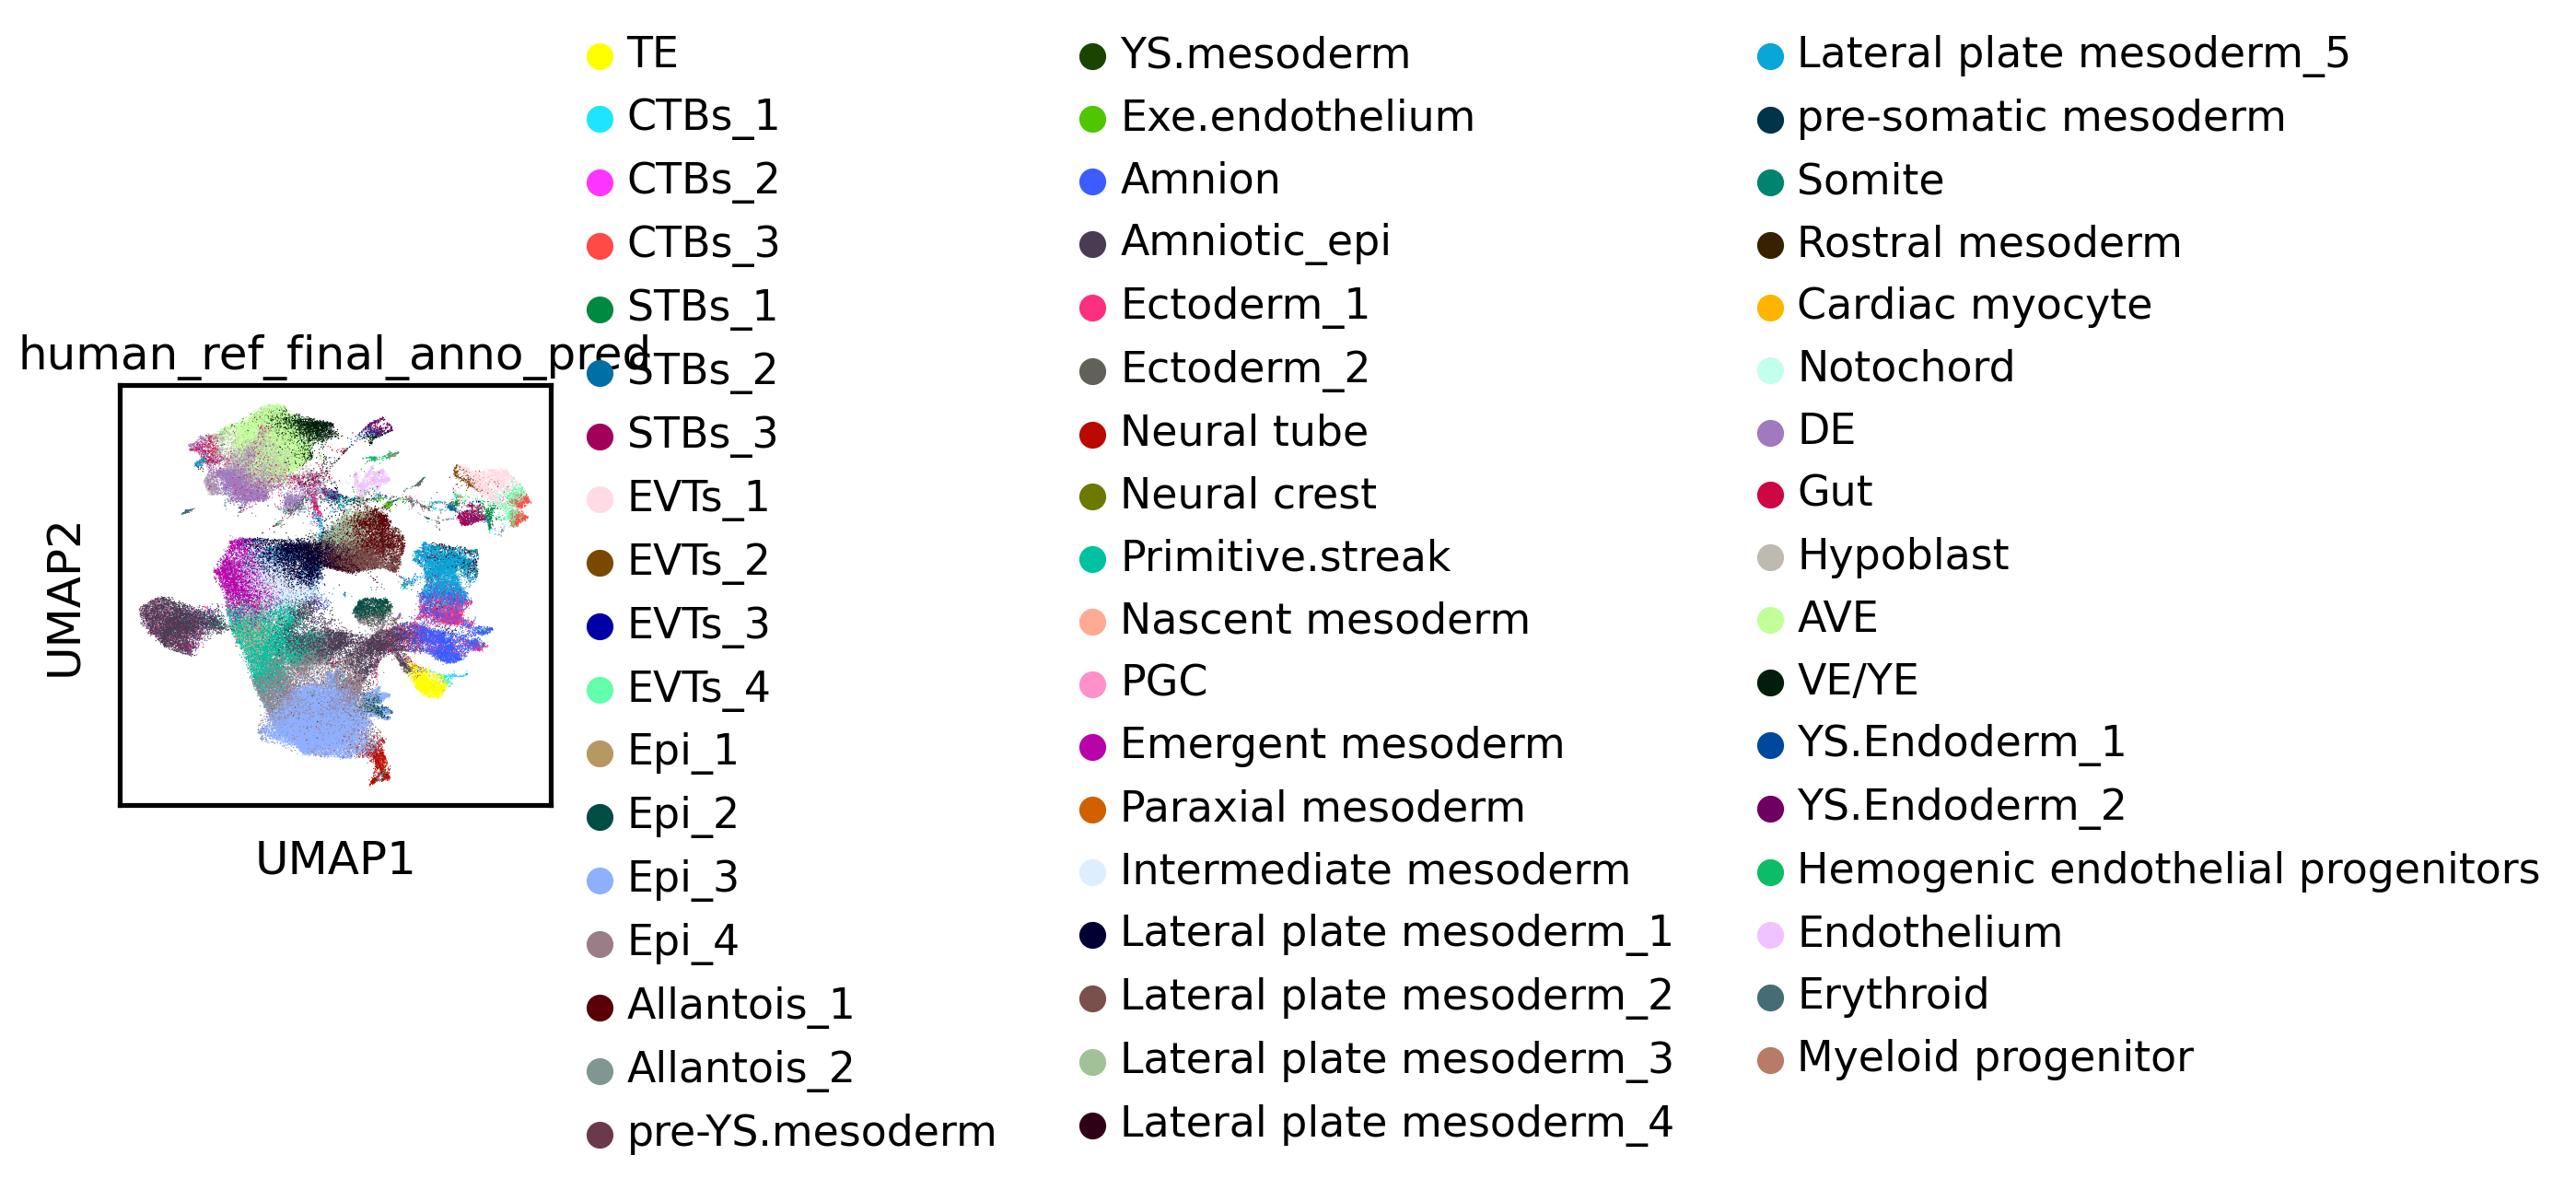

In [12]:
sc.pl.umap(adata, color=['human_ref_final_anno_pred'],save="scpoli_human_ref_final_anno_pred.pdf")

/home/liuxiaodongLab/fanxueying/miniconda3/envs/benchmarking/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


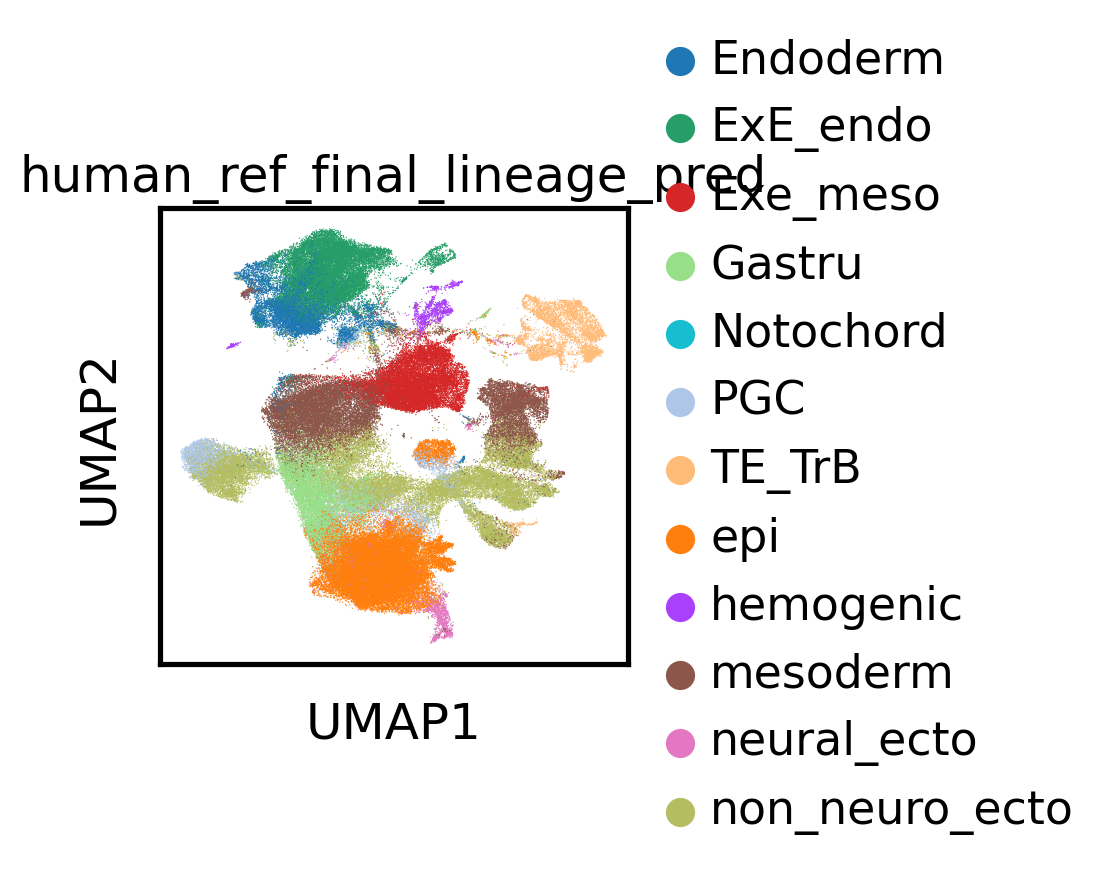

In [13]:
# Define the lineage color mapping
lineage_color_mapping = {
    "Endoderm": "#1f77b4",
    "epi": "#ff7f0e",
    "ExE_endo": "#279e68",
    "Exe_meso": "#d62728",
    "hemogenic": "#aa40fc",
    "mesoderm": "#8c564b",
    "neural_ecto": "#e377c2",
    "non_neuro_ecto": "#b5bd61",
    "Notochord": "#17becf",
    "PGC": "#aec7e8",
    "TE_TrB": "#ffbb78",
    "Gastru": "#98df8a"
}
# Ensure the column exists in adata.obs
if 'human_ref_final_lineage_pred' not in adata.obs.columns:
    raise ValueError("Column 'human_ref_final_lineage_pred' not found in adata.obs.")

# Create a color vector based on the lineage_color_mapping
adata.uns['human_ref_final_lineage_pred_colors'] = [
    lineage_color_mapping[cat] for cat in adata.obs['human_ref_final_lineage_pred'].cat.categories
]
sc.pl.umap(adata, color=['human_ref_final_lineage_pred'],save="scpoli_human_ref_final_lineage_pred.pdf")

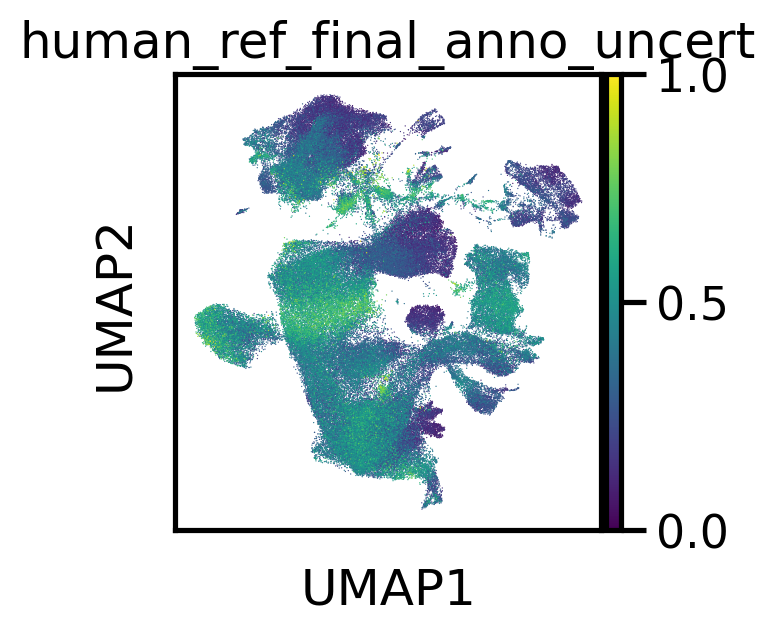

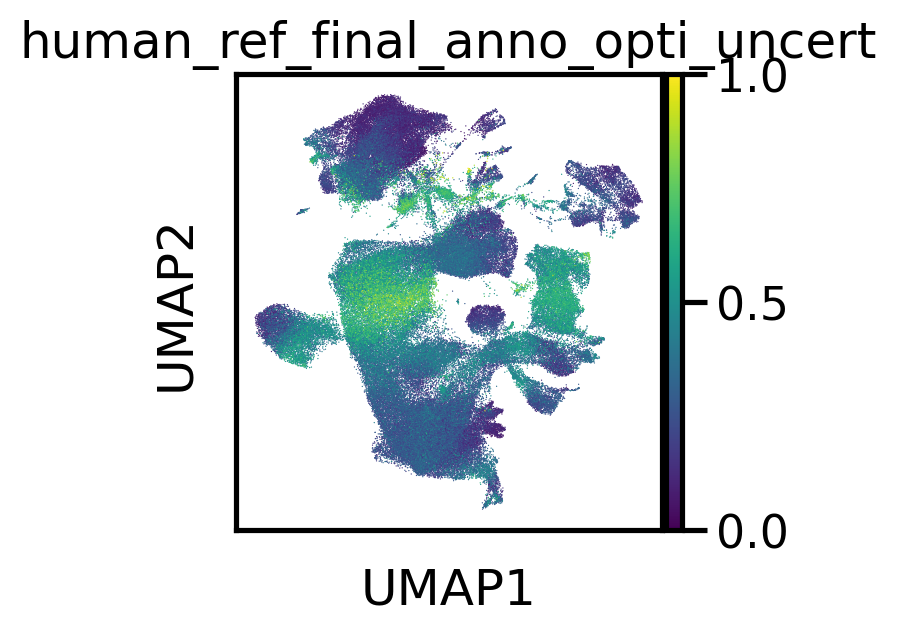

In [14]:
sc.pl.umap(adata, color=['human_ref_final_anno_uncert'],save="scpoli_human_ref_final_anno_uncert.pdf")
sc.pl.umap(adata, color=['human_ref_final_anno_opti_uncert'],save="scpoli_human_ref_final_anno_uncert_enhanced.pdf")

In [15]:
adata

AnnData object with n_obs × n_vars = 142232 × 35142
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'human_ref_final_lineage_pred', 'human_ref_final_lineage_uncert', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'batch', 'Unintegrated_res_0.5', 'scANVI_res_0.5', 'human_ref_final_anno_pred', 'human_ref_final_anno_uncert', 'leiden_res_0.80', 'leiden_res_1.00', 'leiden_res_1.50', 'human_ref_final_lineage_opti_pred', 'human_ref_final_lineage_opti_uncert', 'human_ref_final_anno_opti_pred', 'human_ref_final_anno_opti_uncert', 'scANVI_res_0.5_opti'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'human_ref_final_anno_pred_colors', 'human_ref_final_lineage_pred_colors', 'hvg', 'leiden', 'leiden_res_0.80_colors', 'leiden_re

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create output directory if it doesn't exist
os.makedirs("uncertainty_analysis", exist_ok=True)

# Function to calculate percentage of cells with uncertainty below threshold
def calculate_low_uncertainty_percentage(adata, uncertainty_key, threshold=0.2, group_key=None):
    """
    Calculate percentage of cells with uncertainty below threshold
    
    Parameters:
    -----------
    adata: AnnData object
    uncertainty_key: Key in adata.obs for uncertainty values
    threshold: Uncertainty threshold (default: 0.2)
    group_key: Optional key in adata.obs for grouping results
    
    Returns:
    --------
    DataFrame with percentages of low-uncertainty cells
    """
    if group_key is None:
        # Calculate for the whole dataset
        total_cells = adata.n_obs
        low_uncert_cells = sum(adata.obs[uncertainty_key] < threshold)
        percentage = (low_uncert_cells / total_cells) * 100
        
        return pd.DataFrame({
            'Group': ['All Cells'],
            'Total Cells': [total_cells],
            'Low Uncertainty Cells': [low_uncert_cells],
            'Percentage': [percentage]
        })
    else:
        # Calculate by group
        result_data = []
        
        # First calculate for all cells
        total_cells = adata.n_obs
        low_uncert_cells = sum(adata.obs[uncertainty_key] < threshold)
        all_percentage = (low_uncert_cells / total_cells) * 100
        
        result_data.append({
            'Group': 'All Cells',
            'Total Cells': total_cells,
            'Low Uncertainty Cells': low_uncert_cells,
            'Percentage': all_percentage
        })
        
        # Then calculate for each group
        group_counts = adata.obs[group_key].value_counts()
        
        for group, count in group_counts.items():
            group_mask = (adata.obs[group_key] == group)
            group_low_uncert = sum(adata.obs.loc[group_mask, uncertainty_key] < threshold)
            group_percentage = (group_low_uncert / count) * 100
            
            result_data.append({
                'Group': group,
                'Total Cells': count,
                'Low Uncertainty Cells': group_low_uncert,
                'Percentage': group_percentage
            })
        
        return pd.DataFrame(result_data)

# Calculate percentage of low-uncertainty cells for non-optimized
non_optimized = calculate_low_uncertainty_percentage(
    adata, 
    uncertainty_key='human_ref_final_anno_uncert',
    threshold=0.1,
    group_key='human_ref_final_lineage_pred'  # Optional: break down by lineage
)
non_optimized['Version'] = 'Non-optimized'

# Calculate percentage of low-uncertainty cells for optimized
optimized = calculate_low_uncertainty_percentage(
    adata, 
    uncertainty_key='human_ref_final_anno_opti_uncert',
    threshold=0.2,
    group_key='human_ref_final_lineage_opti_pred'  # Use the same grouping for comparison
)
optimized['Version'] = 'Optimized'

# Combine results
combined_results = pd.concat([non_optimized, optimized])

# Save results to CSV
combined_results.to_csv("uncertainty_analysis/low_uncertainty_percentages.csv", index=False)


In [25]:
combined_results

,Group,Total Cells,Low Uncertainty Cells,Percentage,Version
0,All Cells,142232,8893,6.252461,Non-optimized
1,epi,30555,2496,8.168876,Non-optimized
2,non_neuro_ecto,24238,329,1.357373,Non-optimized
3,mesoderm,21965,122,0.555429,Non-optimized
4,ExE_endo,18732,2685,14.333760,Non-optimized
5,Exe_meso,14000,2675,19.107143,Non-optimized
6,Endoderm,9669,18,0.186162,Non-optimized
7,Gastru,9667,28,0.289645,Non-optimized
8,PGC,5128,34,0.663027,Non-optimized
9,TE_TrB,4992,406,8.133013,Non-optimized



Percentage of cells with uncertainty < 0.2:
         Version  Percentage
0  Non-optimized    6.252461
0      Optimized   36.732943

Absolute improvement: 30.48%
Relative improvement: 5.87x

Analysis complete! Results saved to 'uncertainty_analysis' directory.


<Figure size 1400x800 with 0 Axes>

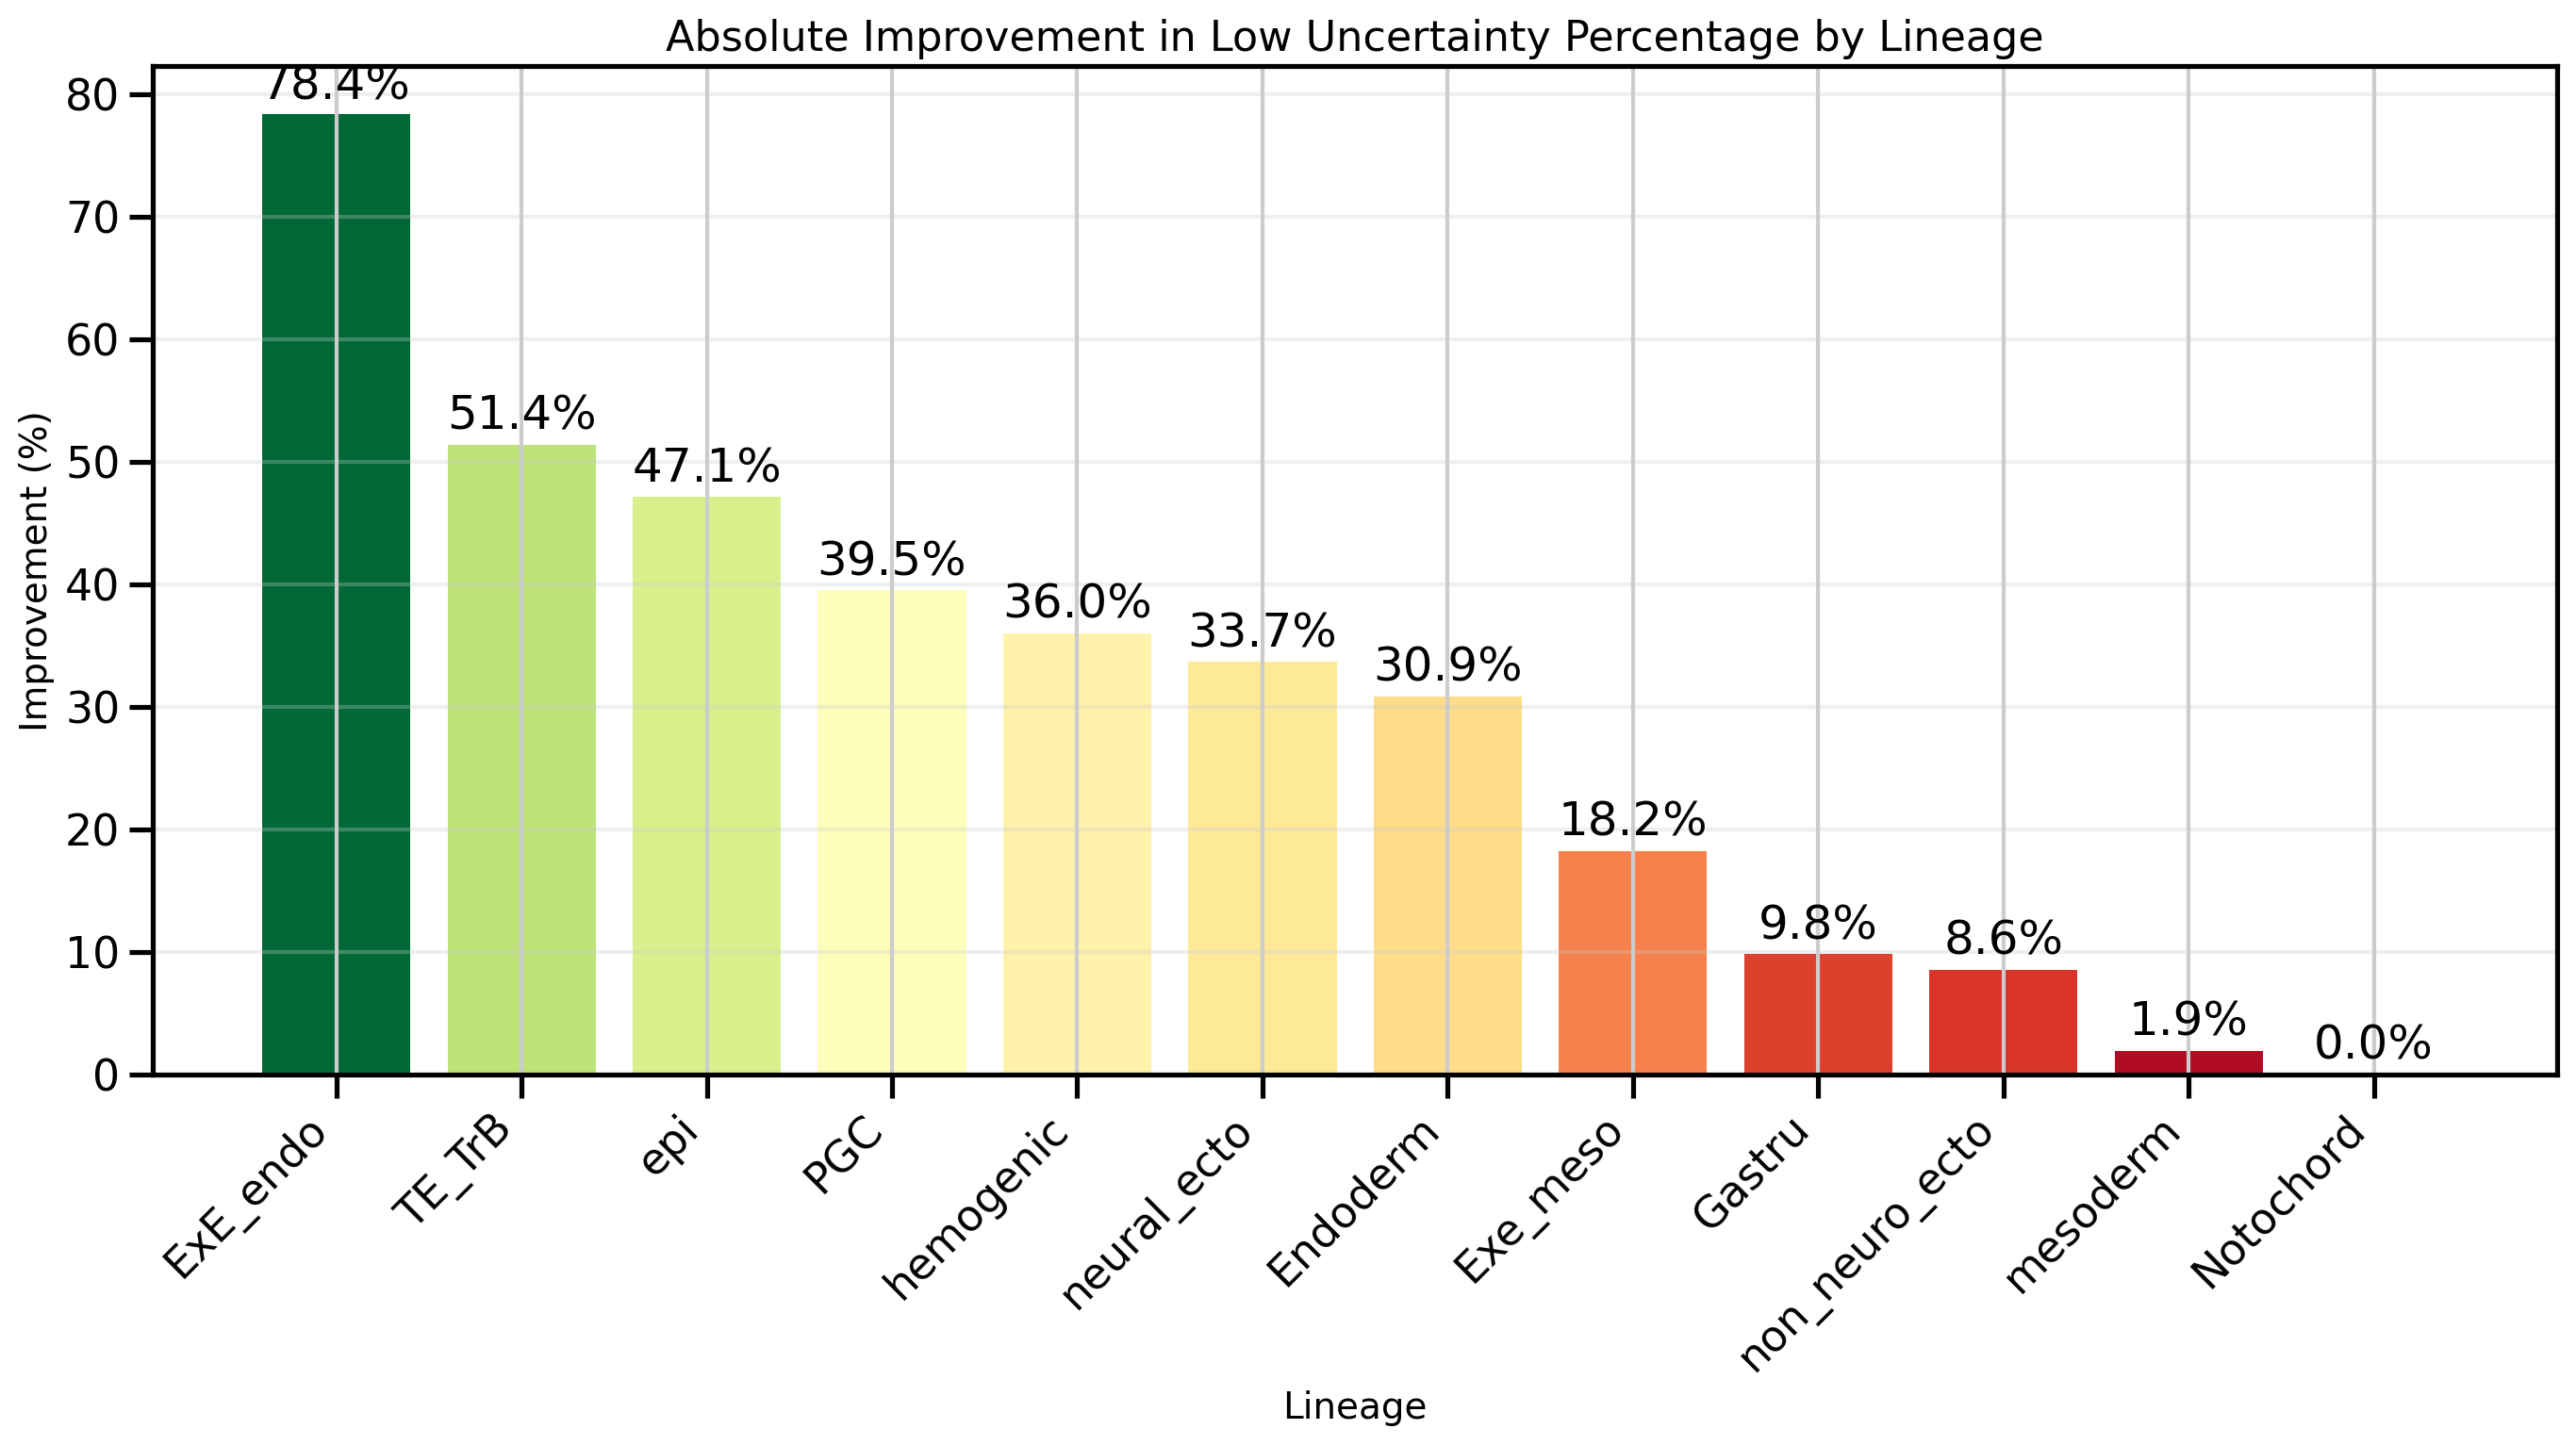

In [26]:
# Print overall results
print("\nPercentage of cells with uncertainty < 0.2:")
print(combined_results[combined_results['Group'] == 'All Cells'][['Version', 'Percentage']])

# Calculate improvement
non_opt_overall = non_optimized[non_optimized['Group'] == 'All Cells']['Percentage'].values[0]
opt_overall = optimized[optimized['Group'] == 'All Cells']['Percentage'].values[0]
improvement_percentage = opt_overall - non_opt_overall
improvement_fold = opt_overall / non_opt_overall

print(f"\nAbsolute improvement: {improvement_percentage:.2f}%")
print(f"Relative improvement: {improvement_fold:.2f}x")

# Create a bar plot comparing overall percentages
plt.figure(figsize=(10, 6))

# Extract just the overall percentages
overall_data = combined_results[combined_results['Group'] == 'All Cells'].copy()

# Create the bar plot
sns.barplot(
    x='Version', y='Percentage', 
    data=overall_data,
    palette=['#3498db', '#2ecc71']  # Blue for non-optimized, green for optimized
)

# Add value labels on top of bars
for i, row in enumerate(overall_data.itertuples()):
    plt.text(
        i, row.Percentage + 1, 
        f"{row.Percentage:.2f}%",
        ha='center', 
        fontsize=12
    )

# Customize the plot
plt.title('Percentage of Cells with Low Uncertainty (<0.2)', fontsize=16)
plt.xlabel('', fontsize=14)
plt.ylabel('Percentage of Cells (%)', fontsize=14)
plt.ylim(0, max(non_opt_overall, opt_overall) * 1.2)  # Set y-axis limit with some headroom
plt.grid(axis='y', alpha=0.3)

# Add annotation showing the improvement
plt.figtext(
    0.5, 0.01,
    f"Improvement: +{improvement_percentage:.2f}% (×{improvement_fold:.2f})",
    ha='center',
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5')
)

plt.tight_layout()
plt.savefig("uncertainty_analysis/low_uncertainty_comparison.png", dpi=300)
plt.savefig("uncertainty_analysis/low_uncertainty_comparison.pdf")
plt.close()

# Create a bar plot comparing percentages by lineage
plt.figure(figsize=(14, 8))

# Filter out the "All Cells" group and prepare data for plotting
lineage_data = combined_results[combined_results['Group'] != 'All Cells'].copy()

# Sort by non-optimized percentage
lineage_order = non_optimized[non_optimized['Group'] != 'All Cells'].sort_values('Percentage')['Group'].tolist()
lineage_data['Group'] = pd.Categorical(lineage_data['Group'], categories=lineage_order, ordered=True)

# Create the grouped bar plot
sns.barplot(
    x='Group', y='Percentage', hue='Version',
    data=lineage_data,
    palette=['#3498db', '#2ecc71'],  # Blue for non-optimized, green for optimized
    order=lineage_order
)

# Customize the plot
plt.title('Percentage of Cells with Low Uncertainty (<0.1) by Lineage', fontsize=16)
plt.xlabel('Lineage', fontsize=14)
plt.ylabel('Percentage of Cells (%)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.legend(title='Version')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("uncertainty_analysis/low_uncertainty_by_lineage.png", dpi=300)
plt.savefig("uncertainty_analysis/low_uncertainty_by_lineage.pdf")
plt.close()

# Calculate and plot the improvement for each lineage
plt.figure(figsize=(14, 8))

# Calculate improvement for each lineage
improvement_data = []

for group in lineage_order:
    non_opt_value = non_optimized[non_optimized['Group'] == group]['Percentage'].values[0]
    opt_value = optimized[optimized['Group'] == group]['Percentage'].values[0]
    abs_improvement = opt_value - non_opt_value
    rel_improvement = abs_improvement / non_opt_value if non_opt_value > 0 else float('inf')
    
    improvement_data.append({
        'Lineage': group,
        'Absolute Improvement (%)': abs_improvement,
        'Relative Improvement': rel_improvement
    })

improvement_df = pd.DataFrame(improvement_data)

# Sort by absolute improvement
improvement_df = improvement_df.sort_values('Absolute Improvement (%)', ascending=False)
lineage_order_by_improvement = improvement_df['Lineage'].tolist()

# Create the bar plot for absolute improvement
plt.figure(figsize=(14, 8))
bars = plt.bar(
    improvement_df['Lineage'], 
    improvement_df['Absolute Improvement (%)'],
    color=[plt.cm.RdYlGn(x/max(improvement_df['Absolute Improvement (%)'])) for x in improvement_df['Absolute Improvement (%)']]
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2., 
        height + 0.5,
        f"{height:.1f}%", 
        ha='center', 
        va='bottom'
    )

plt.title('Absolute Improvement in Low Uncertainty Percentage by Lineage', fontsize=16)
plt.xlabel('Lineage', fontsize=14)
plt.ylabel('Improvement (%)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("uncertainty_analysis/lineage_improvement.png", dpi=300)
plt.savefig("uncertainty_analysis/lineage_improvement.pdf")

print("\nAnalysis complete! Results saved to 'uncertainty_analysis' directory.")

In [28]:
# Calculate percentage of low-uncertainty cells for non-optimized
non_optimized = calculate_low_uncertainty_percentage(
    adata, 
    uncertainty_key='human_ref_final_lineage_uncert',
    threshold=0.1,
    group_key='human_ref_final_lineage_pred'  # Optional: break down by lineage
)
non_optimized['Version'] = 'Non-optimized'

# Calculate percentage of low-uncertainty cells for optimized
optimized = calculate_low_uncertainty_percentage(
    adata, 
    uncertainty_key='human_ref_final_lineage_opti_uncert',
    threshold=0.2,
    group_key='human_ref_final_lineage_opti_pred'  # Use the same grouping for comparison
)
optimized['Version'] = 'Optimized'

# Combine results
combined_results = pd.concat([non_optimized, optimized])
combined_results

,Group,Total Cells,Low Uncertainty Cells,Percentage,Version
0,All Cells,142232,7065,4.967237,Non-optimized
1,epi,30555,3052,9.988545,Non-optimized
2,non_neuro_ecto,24238,493,2.033996,Non-optimized
3,mesoderm,21965,0,0.000000,Non-optimized
4,ExE_endo,18732,3015,16.095452,Non-optimized
5,Exe_meso,14000,67,0.478571,Non-optimized
6,Endoderm,9669,264,2.730375,Non-optimized
7,Gastru,9667,96,0.993069,Non-optimized
8,PGC,5128,34,0.663027,Non-optimized
9,TE_TrB,4992,0,0.000000,Non-optimized


In [29]:
# Print overall results
print("\nPercentage of cells with uncertainty < 0.2:")
print(combined_results[combined_results['Group'] == 'All Cells'][['Version', 'Percentage']])

# Calculate improvement
non_opt_overall = non_optimized[non_optimized['Group'] == 'All Cells']['Percentage'].values[0]
opt_overall = optimized[optimized['Group'] == 'All Cells']['Percentage'].values[0]
improvement_percentage = opt_overall - non_opt_overall
improvement_fold = opt_overall / non_opt_overall

print(f"\nAbsolute improvement: {improvement_percentage:.2f}%")
print(f"Relative improvement: {improvement_fold:.2f}x")

# Create a bar plot comparing overall percentages
plt.figure(figsize=(10, 6))

# Extract just the overall percentages
overall_data = combined_results[combined_results['Group'] == 'All Cells'].copy()

# Create the bar plot
sns.barplot(
    x='Version', y='Percentage', 
    data=overall_data,
    palette=['#3498db', '#2ecc71']  # Blue for non-optimized, green for optimized
)

# Add value labels on top of bars
for i, row in enumerate(overall_data.itertuples()):
    plt.text(
        i, row.Percentage + 1, 
        f"{row.Percentage:.2f}%",
        ha='center', 
        fontsize=12
    )

# Customize the plot
plt.title('Percentage of Cells with Low Uncertainty (<0.2)', fontsize=16)
plt.xlabel('', fontsize=14)
plt.ylabel('Percentage of Cells (%)', fontsize=14)
plt.ylim(0, max(non_opt_overall, opt_overall) * 1.2)  # Set y-axis limit with some headroom
plt.grid(axis='y', alpha=0.3)

# Add annotation showing the improvement
plt.figtext(
    0.5, 0.01,
    f"Improvement: +{improvement_percentage:.2f}% (×{improvement_fold:.2f})",
    ha='center',
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5')
)

plt.tight_layout()
plt.savefig("uncertainty_analysis/low_uncertainty_comparison_lineage.png", dpi=300)
plt.savefig("uncertainty_analysis/low_uncertainty_comparison_lineage.pdf")
plt.close()



Percentage of cells with uncertainty < 0.2:
         Version  Percentage
0  Non-optimized    4.967237
0      Optimized   31.527364

Absolute improvement: 26.56%
Relative improvement: 6.35x


In [27]:
# Create output directory if it doesn't exist
os.makedirs("annotation_analysis", exist_ok=True)

# Define lineages and their annotations
lineages = {
    'TE_TrB': ['TE','CTBs_1', 'CTBs_2', 'CTBs_3', 'STBs_1', 'STBs_2', 'STBs_3', 'EVTs_1', 'EVTs_2', 'EVTs_3', 'EVTs_4'],
    'epi': ['Epi_1', 'Epi_2', 'Epi_3','Epi_4'],
    'Gastru': ['Primitive.streak', 'Nascent mesoderm'],
    'Notochord': ['Notochord'],
    'PGC': ['PGC'],
    'ExE_endo': ['Hypoblast', 'AVE', 'VE/YE', 'YS.Endoderm_1', 'YS.Endoderm_2'],
    'Exe_meso': ['Allantois_1', 'Allantois_2', 'pre-YS.mesoderm', 'YS.mesoderm', 'Exe.endothelium'],
    'non_neuro_ecto': ['Amnion', 'Amniotic_epi', 'Ectoderm_1', 'Ectoderm_2'],
    'neural_ecto': ['Neural tube', 'Neural crest'],
    'Endoderm': ['DE', 'Gut'],
    'mesoderm': ['Emergent mesoderm', 'Paraxial mesoderm', 'Intermediate mesoderm', 'Lateral plate mesoderm_1',
                  'Lateral plate mesoderm_2', 'Lateral plate mesoderm_3', 'Lateral plate mesoderm_4',
                  'Lateral plate mesoderm_5', 'pre-somatic mesoderm', 'Somite', 'Rostral mesoderm',
                  'Cardiac myocyte'],
    'hemogenic': ['Hemogenic endothelial progenitors', 'Endothelium', 'Erythroid', 'Myeloid progenitor'],
}

# Create a mapping from annotation to lineage
anno_to_lineage = {}
for lineage, annos in lineages.items():
    for anno in annos:
        anno_to_lineage[anno] = lineage

# Function to validate annotation-lineage consistency
def check_annotation_lineage_consistency(adata, anno_key, lineage_key, anno_to_lineage_map):
    """
    Check if annotation assignments are consistent with lineage assignments
    
    Parameters:
    -----------
    adata: AnnData object
    anno_key: Key in adata.obs for annotation
    lineage_key: Key in adata.obs for lineage
    anno_to_lineage_map: Dictionary mapping annotations to lineages
    
    Returns:
    --------
    DataFrame with consistency results
    """
    # Create a dataframe with the relevant columns
    df = pd.DataFrame({
        'annotation': adata.obs[anno_key],
        'lineage': adata.obs[lineage_key]
    })
    
    # Function to check if an annotation belongs to its assigned lineage
    def is_consistent(row):
        anno = row['annotation']
        lineage = row['lineage']
        
        # Handle missing values
        if pd.isna(anno) or pd.isna(lineage):
            return np.nan
        
        # Check if annotation exists in our mapping
        if anno not in anno_to_lineage_map:
            return False
        
        # Check if assigned lineage matches expected lineage
        return anno_to_lineage_map[anno] == lineage
    
    # Apply the consistency check
    df['is_consistent'] = df.apply(is_consistent, axis=1)
    
    # Calculate overall statistics
    total_cells = len(df)
    valid_cells = df['is_consistent'].count()  # Excluding NaN values
    consistent_cells = df['is_consistent'].sum()
    
    consistency_rate = consistent_cells / valid_cells if valid_cells > 0 else np.nan
    
    # Calculate per-lineage statistics
    lineage_stats = df.groupby('lineage').agg(
        total_cells=('is_consistent', 'count'),
        consistent_cells=('is_consistent', 'sum')
    ).reset_index()
    
    lineage_stats['consistency_rate'] = lineage_stats['consistent_cells'] / lineage_stats['total_cells']
    lineage_stats['percent_consistent'] = lineage_stats['consistency_rate'] * 100
    
    # Calculate per-annotation statistics
    anno_stats = df.groupby('annotation').agg(
        total_cells=('is_consistent', 'count'),
        consistent_cells=('is_consistent', 'sum')
    ).reset_index()
    
    anno_stats['consistency_rate'] = anno_stats['consistent_cells'] / anno_stats['total_cells']
    anno_stats['percent_consistent'] = anno_stats['consistency_rate'] * 100
    
    # Add expected lineage to annotation statistics
    anno_stats['expected_lineage'] = anno_stats['annotation'].map(
        lambda x: anno_to_lineage_map.get(x, "Unknown")
    )
    
    # Get actual lineage assignments for each annotation
    anno_lineage_counts = df.groupby(['annotation', 'lineage']).size().reset_index(name='count')
    
    # For each annotation, find the most common lineage assignment
    most_common_lineage = anno_lineage_counts.sort_values('count', ascending=False).groupby('annotation').first()
    anno_stats = anno_stats.merge(
        most_common_lineage[['lineage', 'count']],
        left_on='annotation',
        right_index=True,
        how='left'
    )
    anno_stats.rename(columns={'lineage': 'most_common_lineage', 'count': 'most_common_count'}, inplace=True)
    
    anno_stats['percent_most_common'] = anno_stats['most_common_count'] / anno_stats['total_cells'] * 100
    
    return {
        'overall_consistency': consistency_rate * 100,  # Convert to percentage
        'lineage_stats': lineage_stats,
        'anno_stats': anno_stats,
        'detailed_data': df
    }

# Check consistency for original predictions
original_results = check_annotation_lineage_consistency(
    adata, 
    anno_key='human_ref_final_anno_pred',
    lineage_key='human_ref_final_lineage_pred',
    anno_to_lineage_map=anno_to_lineage
)

# Check consistency for optimized predictions
optimized_results = check_annotation_lineage_consistency(
    adata, 
    anno_key='human_ref_final_anno_opti_pred',
    lineage_key='human_ref_final_lineage_opti_pred',
    anno_to_lineage_map=anno_to_lineage
)

# Print overall results
print(f"\nOriginal Annotation-Lineage Consistency: {original_results['overall_consistency']:.2f}%")
print(f"Optimized Annotation-Lineage Consistency: {optimized_results['overall_consistency']:.2f}%")
print(f"Improvement: {optimized_results['overall_consistency'] - original_results['overall_consistency']:.2f}%")

# Create a summary table comparing original and optimized results
lineage_comparison = pd.merge(
    original_results['lineage_stats'], 
    optimized_results['lineage_stats'],
    on='lineage',
    suffixes=('_original', '_optimized')
)




Original Annotation-Lineage Consistency: 78.76%
Optimized Annotation-Lineage Consistency: 76.64%
Improvement: -2.12%
